## Pipeline 4B — Social Media Timing Optimizer (Predictive)

This notebook trains a predictive model to estimate `engagement_rate` from **timing + format** features only, then saves artifacts and (optionally) runs inference to pre-compute a full platform × day × hour recommendation matrix.

### Files this notebook uses
- `ml/social_media_timing/features.py`
- `ml/social_media_timing/etl.py`
- `ml/social_media_timing/artifacts.py`
- `ml/social_media_timing/infer.py`
- `ml/utils_db.py`, `ml/config.py`

### Target
- `engagement_rate` (continuous)

### Notes
- This pipeline intentionally **excludes content features** (sentiment/topic/etc.). Use Pipeline 4 for content guidance.


## 1) Problem framing

**Business question:** Given the platform, day of week, and time of day, what engagement rate can we expect — and what combination maximizes reach?

**Why engagement_rate (not donation_referrals):** Engagement rate is consistently measured by every platform, so it’s always available even when donation tracking/UTMs vary.

**Separation from Pipeline 4:**
- Pipeline 4 focuses on **what to post** (content features) and interpretability.
- Pipeline 4B focuses on **when/where to post** (timing/format features) and prediction accuracy.


## Setup — install required packages

Run this once per environment/kernel. It installs the repo’s ML dependencies from `ml/requirements.txt`.


In [1]:
# Ensure the repo root is on sys.path so `import ml...` works
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()

# Walk upward until we find the repo root containing the `ml/` package directory
repo_root = None
for p in [cwd, *cwd.parents]:
    if (p / "ml" / "__init__.py").exists():
        repo_root = p
        break

if repo_root is None:
    raise RuntimeError(f"Could not find repo root containing ml/__init__.py starting from {cwd}")

sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

print("Repo root:", repo_root)
print("Python:", sys.executable)
print("CWD:", Path.cwd())


Repo root: /Users/brytongustin/Downloads/Winter_Junior_Core/INTEX II/intex2
Python: /usr/local/bin/python3.12
CWD: /Users/brytongustin/Downloads/Winter_Junior_Core/INTEX II/intex2


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import RFECV, SelectKBest, VarianceThreshold, f_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    TimeSeriesSplit,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from ml.social_media_timing.artifacts import save_metadata, save_metrics, save_model_bundle
from ml.social_media_timing.etl import fetch_training_raw
from ml.social_media_timing.features import FEATURE_COLUMNS, build_features
from ml.social_media_timing.infer import run_inference

SEED = 42

print("Imports OK")


Imports OK


## 2) Data acquisition & preparation

This fetches the raw `social_media_posts` table, drops unlabeled rows, preserves `created_at` for chronological evaluation when available, and then builds the raw modeling frame.

- X features: platform, post_hour, day_of_week, media_type, is_boosted, boost_budget_php, has_call_to_action, post_type, is_weekend
- y target: engagement_rate
- encoding/scaling/selection are learned later inside sklearn pipelines


In [3]:
raw = fetch_training_raw().copy()
raw["engagement_rate_numeric"] = pd.to_numeric(raw.get("engagement_rate"), errors="coerce")
raw["created_at_parsed"] = pd.to_datetime(raw.get("created_at"), errors="coerce")

modeling_raw = raw.loc[raw["engagement_rate_numeric"].notna()].copy()
use_time_split = modeling_raw["created_at_parsed"].notna().sum() >= max(50, int(len(modeling_raw) * 0.8))

if use_time_split:
    modeling_raw = modeling_raw.sort_values("created_at_parsed").reset_index(drop=True)
else:
    modeling_raw = modeling_raw.reset_index(drop=True)

X, y = build_features(modeling_raw)
created_at = modeling_raw["created_at_parsed"].reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y mean:", float(np.mean(y)))
print("chronological split:", use_time_split)

assert list(X.columns) == FEATURE_COLUMNS
assert len(X) == len(y) == len(created_at)
assert np.isfinite(y).all()

X.head()


X shape: (812, 9)
y shape: (812,)
y mean: 0.09898017241379312
chronological split: True


,platform,post_hour,day_of_week,media_type,is_boosted,boost_budget_php,has_call_to_action,post_type,is_weekend
0,WhatsApp,18,Thursday,Text,0,0.00,1,FundraisingAppeal,0
1,Instagram,11,Friday,Photo,0,0.00,0,EducationalContent,0
2,LinkedIn,10,Sunday,Text,0,0.00,0,EventPromotion,1
3,Instagram,15,Monday,Video,0,0.00,0,ThankYou,0
4,TikTok,15,Monday,Reel,1,4030.64,1,ThankYou,0


## 3) Exploration

The pipeline spec documents these confirmed findings (from the dataset):
- `post_hour` vs `engagement_rate`: r = 0.444 (dominant signal)
- Best days by engagement: Saturday (0.1057), Friday (0.1046), Sunday (0.1029)

The cells below compute a few quick checks so you can validate your environment + data.


In [9]:
# Correlation proxy for post_hour using the raw (non-one-hot) column if present
# Here post_hour exists as numeric in X by design.
if "post_hour" in X.columns:
    r = np.corrcoef(X["post_hour"].astype(float).values, y.astype(float).values)[0, 1]
    print("corr(post_hour, engagement_rate) =", float(r))

# Weekend vs weekday mean
if "is_weekend" in X.columns:
    weekend_mean = float(y[X["is_weekend"].astype(int).eq(1)].mean())
    weekday_mean = float(y[X["is_weekend"].astype(int).eq(0)].mean())
    print("mean engagement (weekend):", weekend_mean)
    print("mean engagement (weekday):", weekday_mean)


corr(post_hour, engagement_rate) = 0.4437435019119868
mean engagement (weekend): 0.10437935779816514
mean engagement (weekday): 0.09699865319865321


## 4) Train/test split

We freeze a holdout test set first. If `created_at` is available for most rows, the split is chronological and cross-validation uses `TimeSeriesSplit`; otherwise it falls back to a reproducible shuffled 5-fold split.


In [10]:
if use_time_split:
    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx].reset_index(drop=True)
    X_test = X.iloc[split_idx:].reset_index(drop=True)
    y_train = y.iloc[:split_idx].reset_index(drop=True)
    y_test = y.iloc[split_idx:].reset_index(drop=True)
    created_at_train = created_at.iloc[:split_idx].reset_index(drop=True)
    created_at_test = created_at.iloc[split_idx:].reset_index(drop=True)
    cv = TimeSeriesSplit(n_splits=5)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=SEED,
    )
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    created_at_train = pd.Series(index=X_train.index, dtype="datetime64[ns]")
    created_at_test = pd.Series(index=X_test.index, dtype="datetime64[ns]")
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

num_cols = ["post_hour", "boost_budget_php", "is_boosted", "has_call_to_action", "is_weekend"]
cat_cols = ["platform", "day_of_week", "media_type", "post_type"]


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                cat_cols,
            ),
        ]
    )


print("train:", X_train.shape, "test:", X_test.shape)
print("cv splitter:", cv)


train: (649, 9) test: (163, 9)
cv splitter: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


## 5) Feature Selection

Follow the Chapter 16 pattern on the training data only:
- `VarianceThreshold` after preprocessing
- univariate ranking with `SelectKBest(f_regression)`
- `RFECV` with the primary model family
- the selected feature count then flows into leakage-safe pipelines for model tuning


In [11]:
preprocessor_for_analysis = make_preprocessor()
X_train_prepared = preprocessor_for_analysis.fit_transform(X_train)
prepared_feature_names = preprocessor_for_analysis.get_feature_names_out().tolist()

variance_filter = VarianceThreshold()
X_train_var = variance_filter.fit_transform(X_train_prepared)
variance_feature_names = [
    name for name, keep in zip(prepared_feature_names, variance_filter.get_support()) if keep
]
removed_low_variance = [
    name for name, keep in zip(prepared_feature_names, variance_filter.get_support()) if not keep
]

univariate_selector = SelectKBest(score_func=f_regression, k="all")
univariate_selector.fit(X_train_var, y_train)
univariate_ranking = (
    pd.DataFrame(
        {
            "feature": variance_feature_names,
            "f_score": univariate_selector.scores_,
        }
    )
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

rfecv = RFECV(
    estimator=GradientBoostingRegressor(random_state=SEED),
    step=1,
    cv=cv,
    scoring="neg_mean_absolute_error",
    min_features_to_select=5,
)
rfecv.fit(X_train_var, y_train)
rfecv_selected_features = [
    name for name, keep in zip(variance_feature_names, rfecv.support_) if keep
]
selected_k = min(max(5, len(rfecv_selected_features)), len(variance_feature_names))

feature_selection_summary = pd.DataFrame(
    {
        "step": ["prepared", "after_variance_filter", "rfecv_selected"],
        "feature_count": [
            len(prepared_feature_names),
            len(variance_feature_names),
            len(rfecv_selected_features),
        ],
    }
)

print("Removed low-variance features:", removed_low_variance if removed_low_variance else "none")
print("RFECV selected encoded features:", len(rfecv_selected_features))
print("Pipeline k for SelectKBest:", selected_k)
display(feature_selection_summary)
display(univariate_ranking.head(10))
print(rfecv_selected_features)


Removed low-variance features: none
RFECV selected encoded features: 5
Pipeline k for SelectKBest: 5


,step,feature_count
0,prepared,30
1,after_variance_filter,30
2,rfecv_selected,5


,feature,f_score
0,num__post_hour,169.465283
1,num__has_call_to_action,21.521962
2,cat__post_type_Campaign,6.173860
3,cat__platform_Instagram,5.200009
4,cat__post_type_FundraisingAppeal,3.213968
5,cat__post_type_EducationalContent,2.822869
6,cat__day_of_week_Friday,1.791739
7,num__is_boosted,1.741607
8,cat__platform_WhatsApp,1.739687
9,cat__platform_LinkedIn,1.302094


['num__post_hour', 'num__boost_budget_php', 'num__has_call_to_action', 'cat__platform_TikTok', 'cat__platform_YouTube']


## 6) Modeling, Tuning, and Evaluation

This section fixes the original leakage issue by keeping preprocessing and feature selection inside each sklearn pipeline, then tuning every candidate model with cross-validation on the training split only. It also adds the Chapter 11 mean-predictor baseline, true RMSE, permutation importance, and learning/validation-curve diagnostics.


,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,GradientBoosting,0.032116,0.003974,0.403555,0.059920
1,RandomForest,0.032262,0.003211,0.420380,0.031430
2,DecisionTree,0.032270,0.003767,0.375023,0.074072
3,Stacking,0.032673,0.002853,0.416793,0.030677
4,ExtraTrees,0.033002,0.003145,0.403362,0.015508
5,SVR,0.033805,0.004120,0.343231,0.063952
6,AdaBoost,0.033920,0.003869,0.372892,0.043001
7,KNN,0.035219,0.005001,0.305328,0.111408
8,LinearRegression,0.040630,0.002341,0.147423,0.095394


Baseline MAE: 0.04438348284760888
Baseline RMSE: 0.054099132164944615
Baseline R2: -0.0020816479897594053
Selected: GradientBoosting
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'select__k': 5}
Test MAE: 0.03005429776854204
Test RMSE: 0.039801723443562226
Test R2: 0.4575917740035016
Business interp: off by 0.03005429776854204 engagement points on avg; mean engagement is 0.09898017241379312 (~ 30.36395778631105 % of mean)


,feature,importance_mean,importance_std
0,post_hour,0.021574,0.001832
1,has_call_to_action,0.002695,0.000490
2,platform,0.000450,0.000124
3,day_of_week,0.000000,0.000000
4,media_type,0.000000,0.000000
5,is_boosted,0.000000,0.000000
6,boost_budget_php,0.000000,0.000000
7,is_weekend,0.000000,0.000000
8,post_type,-0.000083,0.000164


,train_size,train_mae,validation_mae
0,156,0.025577,0.040051
1,277,0.026442,0.037839
2,398,0.027101,0.040490
3,520,0.027222,0.040763


,param_value,train_mae,validation_mae
0,50,0.029152,0.032369
1,100,0.026945,0.032116
2,150,0.025908,0.032089
3,200,0.025329,0.032196


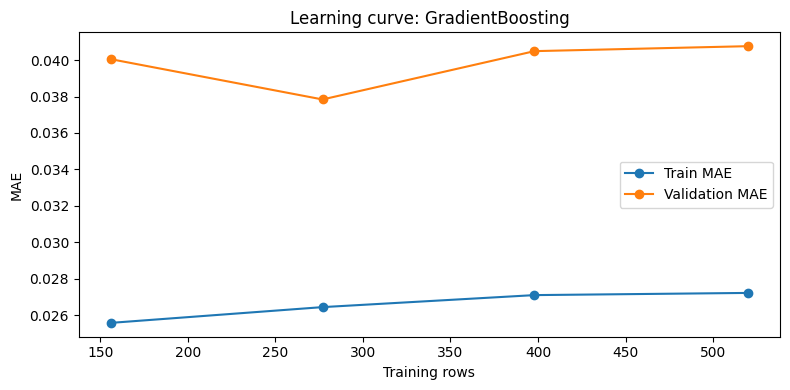

In [15]:
def make_model_pipeline(estimator) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", make_preprocessor()),
            ("variance", VarianceThreshold()),
            ("select", SelectKBest(score_func=f_regression, k=selected_k)),
            ("model", estimator),
        ]
    )


stacking_internal_cv = KFold(n_splits=5, shuffle=False)
stacking_model = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=SEED, n_estimators=200, max_depth=6)),
        ("gbr", GradientBoostingRegressor(random_state=SEED, n_estimators=150, learning_rate=0.05, max_depth=2)),
    ],
    final_estimator=Ridge(alpha=1.0),
    # Stacking uses cross_val_predict internally and needs partition-based folds.
    cv=stacking_internal_cv,
    n_jobs=None,
)


model_searches = {
    "LinearRegression": {
        "pipeline": make_model_pipeline(LinearRegression()),
        "params": {"select__k": [selected_k, "all"]},
    },
    "DecisionTree": {
        "pipeline": make_model_pipeline(DecisionTreeRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 5, 10],
        },
    },
    "KNN": {
        "pipeline": make_model_pipeline(KNeighborsRegressor()),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_neighbors": [5, 9, 15],
            "model__weights": ["uniform", "distance"],
        },
    },
    "SVR": {
        "pipeline": make_model_pipeline(SVR()),
        "params": {
            "select__k": [selected_k, "all"],
            "model__C": [0.5, 1.0, 5.0],
            "model__epsilon": [0.01, 0.02],
            "model__gamma": ["scale", "auto"],
        },
    },
    "RandomForest": {
        "pipeline": make_model_pipeline(RandomForestRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [300],
            "model__max_depth": [4, 6, 8, None],
            "model__min_samples_split": [2, 10, 30],
            "model__min_samples_leaf": [3, 5, 10, 20],
            "model__max_features": ["sqrt", 0.5],
        },
    },
    "GradientBoosting": {
        "pipeline": make_model_pipeline(GradientBoostingRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    },
    "AdaBoost": {
        "pipeline": make_model_pipeline(AdaBoostRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5],
        },
    },
    "ExtraTrees": {
        "pipeline": make_model_pipeline(ExtraTreesRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [300],
            "model__max_depth": [None, 6, 10],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "Stacking": {
        "pipeline": make_model_pipeline(stacking_model),
        "params": {
            "select__k": [selected_k, "all"],
            "model__final_estimator__alpha": [0.1, 1.0, 10.0],
        },
    },
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

fitted_searches: dict[str, GridSearchCV] = {}
comparison_rows: list[dict] = []

for model_name, spec in model_searches.items():
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["params"],
        cv=cv,
        scoring=scoring,
        refit="mae",
        n_jobs=None,
    )
    search.fit(X_train, y_train)
    fitted_searches[model_name] = search

    best_idx = search.best_index_
    comparison_rows.append(
        {
            "model": model_name,
            "cv_mae_mean": float(-search.cv_results_["mean_test_mae"][best_idx]),
            "cv_mae_std": float(search.cv_results_["std_test_mae"][best_idx]),
            "cv_r2_mean": float(search.cv_results_["mean_test_r2"][best_idx]),
            "cv_r2_std": float(search.cv_results_["std_test_r2"][best_idx]),
            "best_params": search.best_params_,
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("cv_mae_mean").reset_index(drop=True)
display(comparison[["model", "cv_mae_mean", "cv_mae_std", "cv_r2_mean", "cv_r2_std"]])

baseline_value = float(y_train.mean())
y_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_value, dtype=float)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_baseline)))
baseline_r2 = r2_score(y_test, y_pred_baseline)
print("Baseline MAE:", float(baseline_mae))
print("Baseline RMSE:", float(baseline_rmse))
print("Baseline R2:", float(baseline_r2))

best_name = str(comparison.iloc[0]["model"])
best_search = fitted_searches[best_name]
best_model = best_search.best_estimator_

y_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
test_r2 = r2_score(y_test, y_pred)

print("Selected:", best_name)
print("Best params:", best_search.best_params_)
print("Test MAE:", float(test_mae))
print("Test RMSE:", float(test_rmse))
print("Test R2:", float(test_r2))

mean_engagement = float(np.mean(y))
if mean_engagement > 0:
    print(
        "Business interp: off by",
        float(test_mae),
        "engagement points on avg; mean engagement is",
        mean_engagement,
        "(~",
        float(test_mae / mean_engagement * 100.0),
        "% of mean)",
    )

pfi = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_mean_absolute_error",
)
pfi_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": pfi.importances_mean,
            "importance_std": pfi.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(pfi_df.head(10))

# --- Learning curve ---
# If we're using time-aware splitting, sklearn.learning_curve + TimeSeriesSplit can produce
# misleadingly small train_sizes. Use an expanding-window curve instead.
if use_time_split:
    val_tail = max(25, int(len(X_train) * 0.2))
    X_lc_train = X_train.iloc[:-val_tail].reset_index(drop=True)
    y_lc_train = y_train.iloc[:-val_tail].reset_index(drop=True)
    X_lc_val = X_train.iloc[-val_tail:].reset_index(drop=True)
    y_lc_val = y_train.iloc[-val_tail:].reset_index(drop=True)

    sizes = [int(s) for s in np.linspace(max(50, int(len(X_lc_train) * 0.3)), len(X_lc_train), 4)]
    rows = []
    for n in sizes:
        m = best_search.best_estimator_
        m.fit(X_lc_train.iloc[:n], y_lc_train.iloc[:n])
        rows.append(
            {
                "train_size": n,
                "train_mae": float(mean_absolute_error(y_lc_train.iloc[:n], m.predict(X_lc_train.iloc[:n]))),
                "validation_mae": float(mean_absolute_error(y_lc_val, m.predict(X_lc_val))),
            }
        )
    learning_curve_df = pd.DataFrame(rows)
else:
    train_sizes, train_scores, valid_scores = learning_curve(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.4, 1.0, 4),
        n_jobs=None,
    )
    learning_curve_df = pd.DataFrame(
        {
            "train_size": train_sizes,
            "train_mae": -train_scores.mean(axis=1),
            "validation_mae": -valid_scores.mean(axis=1),
        }
    )

display(learning_curve_df)

validation_param_map = {
    "LinearRegression": ("select__k", [5, selected_k]),
    "DecisionTree": ("model__max_depth", [2, 3, 4, 5, 6, 8]),
    "KNN": ("model__n_neighbors", [3, 5, 7, 9, 11, 15]),
    "SVR": ("model__C", [0.1, 0.5, 1.0, 5.0, 10.0]),
    "RandomForest": ("model__max_depth", [3, 5, 6, 8, 10]),
    "GradientBoosting": ("model__n_estimators", [50, 100, 150, 200]),
    "AdaBoost": ("model__n_estimators", [50, 100, 150, 200]),
    "ExtraTrees": ("model__max_depth", [3, 5, 6, 8, 10]),
    "Stacking": ("model__final_estimator__alpha", [0.1, 0.5, 1.0, 5.0, 10.0]),
}

if best_name in validation_param_map:
    param_name, param_range = validation_param_map[best_name]
    train_curve, valid_curve = validation_curve(
        best_model,
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=None,
    )
    validation_curve_df = pd.DataFrame(
        {
            "param_value": param_range,
            "train_mae": -train_curve.mean(axis=1),
            "validation_mae": -valid_curve.mean(axis=1),
        }
    )
    display(validation_curve_df)
else:
    validation_curve_df = pd.DataFrame()
    print("No validation curve configured for", best_name)

plt.figure(figsize=(8, 4))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_mae"], marker="o", label="Train MAE")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_mae"], marker="o", label="Validation MAE")
plt.xlabel("Training rows")
plt.ylabel("MAE")
plt.title(f"Learning curve: {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 7) Save Artifacts

This saves the tuned sklearn pipeline plus metadata and metrics. The saved `feature_list` is now the raw feature schema, while the pipeline itself owns the learned preprocessing and selection steps.

In [16]:
feature_list = list(X.columns)

save_model_bundle(best_model, feature_list=feature_list)

_ = save_metadata(
    feature_list=feature_list,
    model_type=best_name,
    train_rows=len(X_train),
    test_rows=len(X_test),
    total_rows=len(X),
)
_ = save_metrics(
    mae=float(test_mae),
    rmse=float(test_rmse),
    r2=float(test_r2),
    cv_table=comparison.to_dict(orient="records"),
)

print("Saved model + metadata + metrics")
print("Raw feature schema:", feature_list)


Saved model + metadata + metrics
Raw feature schema: ['platform', 'post_hour', 'day_of_week', 'media_type', 'is_boosted', 'boost_budget_php', 'has_call_to_action', 'post_type', 'is_weekend']
